# Event-TimeRAF Final Results and Figures

This notebook reads one frozen, manifest-backed final run from the main pipeline. It does not train models or alter predictions, and it rejects mixed run identifiers, non-final runs, or runs that did not complete the frozen-TSFM publication gate.

In [11]:
from pathlib import Path, PurePosixPath
import json
import shutil
import sys
import zipfile
import pandas as pd

RESULTS_ROOT_OVERRIDE = None
REQUIRE_FINAL_PUBLICATION_RUN = True
REQUIRE_PUBLICATION_TITLE_ALLOWED = True

def has_project_files(path):
    return (path / 'configs' / 'default.yaml').exists() and (path / 'src' / 'event_timeraf' / 'config.py').exists()

def reset_directory(path):
    path = path.resolve()
    kaggle_working = Path('/kaggle/working').resolve()
    if path.exists():
        if not path.is_relative_to(kaggle_working):
            raise RuntimeError(f'Refusing to refresh non-working directory: {path}')
        shutil.rmtree(path)
    path.mkdir(parents=True, exist_ok=True)

def locate_results_root():
    if RESULTS_ROOT_OVERRIDE is not None:
        override = Path(RESULTS_ROOT_OVERRIDE).resolve()
        if not has_project_files(override):
            raise FileNotFoundError(f'RESULTS_ROOT_OVERRIDE is missing src/event_timeraf/config.py: {override}')
        return override
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd.parent, Path('/kaggle/working/event_timeraf')]
    kaggle_input = Path('/kaggle/input')
    if kaggle_input.exists():
        candidates.extend(path.parent.parent for path in kaggle_input.rglob('configs/default.yaml'))
    source = next((path for path in candidates if has_project_files(path)), None)
    if source is None and kaggle_input.exists():
        for archive in sorted(kaggle_input.rglob('*.zip')):
            with zipfile.ZipFile(archive) as bundle:
                members = [PurePosixPath(name) for name in bundle.namelist()]
                config_member = next((member for member in members if member.parts[-2:] == ('configs', 'default.yaml')), None)
                package_member = next((member for member in members if member.parts[-3:] == ('src', 'event_timeraf', 'config.py')), None)
                if config_member is None or package_member is None:
                    continue
                if any(member.is_absolute() or '..' in member.parts for member in members):
                    raise RuntimeError(f'Unsafe paths found in attached archive: {archive}')
                extracted = Path('/kaggle/working/event_timeraf_results_source')
                reset_directory(extracted)
                bundle.extractall(extracted)
                source = extracted.joinpath(*config_member.parts[:-2])
                break
    if source is None:
        raise FileNotFoundError('Set RESULTS_ROOT_OVERRIDE to a completed run directory.')
    if kaggle_input.exists() and source.is_relative_to(kaggle_input):
        writable = Path('/kaggle/working/event_timeraf_results')
        writable.mkdir(parents=True, exist_ok=True)
        for directory in ('configs', 'src', 'outputs'):
            if (source / directory).exists():
                target = writable / directory
                if target.exists():
                    shutil.rmtree(target)
                shutil.copytree(source / directory, target)
        return writable
    return source

PROJECT_ROOT = locate_results_root()
PACKAGE_ROOT = PROJECT_ROOT / 'src' / 'event_timeraf'
if not (PACKAGE_ROOT / 'config.py').exists():
    raise FileNotFoundError(f'Package file missing after setup: {PACKAGE_ROOT / "config.py"}')
for module_name in list(sys.modules):
    if module_name == 'event_timeraf' or module_name.startswith('event_timeraf.'):
        del sys.modules[module_name]
sys.path.insert(0, str(PROJECT_ROOT / 'src'))
print({'project_root': str(PROJECT_ROOT), 'package_root': str(PACKAGE_ROOT)})
from event_timeraf.config import load_config
from event_timeraf.plots import plot_horizon_metrics

cfg = load_config(PROJECT_ROOT / 'configs' / 'default.yaml', PROJECT_ROOT)
manifest = json.loads((cfg.paths.outputs / 'logs' / 'run_manifest.json').read_text(encoding='utf-8'))
audit = json.loads((cfg.paths.outputs / 'audit' / 'data_audit.json').read_text(encoding='utf-8'))
metrics = pd.read_csv(cfg.paths.outputs / 'tables' / 'metrics.csv')
predictions = pd.read_parquet(cfg.paths.outputs / 'predictions' / 'predictions.parquet')
explanations = pd.read_parquet(cfg.paths.outputs / 'evidence' / 'explanations.parquet')
ablation = pd.read_csv(cfg.paths.outputs / 'tables' / 'ablation_results.csv')
subset_counts = pd.read_csv(cfg.paths.outputs / 'tables' / 'subset_counts.csv')
drift_results = pd.read_csv(cfg.paths.outputs / 'tables' / 'drift_period_results.csv')
event_results = pd.read_csv(cfg.paths.outputs / 'tables' / 'event_period_results.csv')
run_ids = (
    set(metrics['run_id']) | set(predictions['run_id']) | set(explanations['run_id'])
    | set(ablation['run_id']) | set(subset_counts['run_id'])
    | set(drift_results['run_id']) | set(event_results['run_id'])
)
if run_ids != {manifest['run_id']}:
    raise RuntimeError(f'Mixed or stale run artifacts detected: {sorted(run_ids)} vs manifest {manifest["run_id"]}')
availability_modes = (
    set(metrics['event_availability_mode']) | set(predictions['event_availability_mode'])
    | set(explanations['event_availability_mode'])
)
if availability_modes != {manifest['run_options']['event_availability_mode']}:
    raise RuntimeError(f'Event-availability metadata mismatch: {sorted(availability_modes)}')
run_options = manifest['run_options']
if REQUIRE_FINAL_PUBLICATION_RUN:
    required_true_options = {
        'require_events': run_options.get('require_events'),
        'final_experiment': run_options.get('final_experiment'),
        'retrieval_evidence_reviewed': run_options.get('retrieval_evidence_reviewed'),
        'run_tsf_model': run_options.get('run_tsf_model'),
    }
    failed = [name for name, value in required_true_options.items() if value is not True]
    if failed:
        raise RuntimeError(f'Not a final-publication run; failed manifest options: {failed}')
    if not audit.get('core_ready') or not audit.get('event_ready'):
        raise RuntimeError('Final run failed data-readiness gates in data_audit.json')
if REQUIRE_PUBLICATION_TITLE_ALLOWED and not run_options.get('publication_title_allowed'):
    raise RuntimeError('Frozen-TSFM publication gate did not complete; do not use foundation-model title/claims.')
print({
    'run_id': manifest['run_id'],
    'event_availability_mode': run_options['event_availability_mode'],
    'final_experiment': run_options.get('final_experiment'),
    'run_tsf_model': run_options.get('run_tsf_model'),
    'retrieval_evidence_reviewed': run_options.get('retrieval_evidence_reviewed'),
    'publication_title_allowed': run_options.get('publication_title_allowed'),
})


{'project_root': '/kaggle/working/event_timeraf', 'package_root': '/kaggle/working/event_timeraf/src/event_timeraf'}
{'run_id': '20260723T112033170131Z', 'event_availability_mode': 'retrospective_event_start', 'final_experiment': True, 'run_tsf_model': True, 'retrieval_evidence_reviewed': True, 'publication_title_allowed': True}


,run_id,model,subset,event_availability_mode,n_origins,n_points,horizon,mse,mae,rmse,mape,smape,r2
1092,20260723T112033170131Z,M04_xgb_context,all,retrospective_event_start,7199,172776,overall,26.184621,3.125194,5.117091,180.656206,31.787274,0.379031
1274,20260723T112033170131Z,M07_xgb_cosine,all,retrospective_event_start,7199,172776,overall,26.671928,3.150531,5.164487,181.430972,31.974338,0.367474
1638,20260723T112033170131Z,M08_event_timeraf_no_drift,all,retrospective_event_start,7199,172776,overall,26.677320,3.145102,5.165009,188.207907,31.969097,0.367346
1820,20260723T112033170131Z,M09_event_timeraf_full,all,retrospective_event_start,7199,172776,overall,26.712155,3.148592,5.168380,187.909102,31.996641,0.366520
2366,20260723T112033170131Z,M11_chronos_hybrid_retrieval,all,retrospective_event_start,7199,172776,overall,28.708648,3.208577,5.358045,147.906238,32.752063,0.319173
2184,20260723T112033170131Z,M10_frozen_chronos,all,retrospective_event_start,7199,172776,overall,28.941491,3.204711,5.379730,120.882436,32.868238,0.313652
910,20260723T112033170131Z,M03_xgb_pm25,all,retrospective_event_start,7199,172776,overall,29.948947,3.368193,5.472563,202.508053,33.933791,0.289760
728,20260723T112033170131Z,M06_cosine_retrieval,all,retrospective_event_start,7199,172776,overall,38.083170,3.940445,6.171156,253.299315,39.115267,0.096856
546,20260723T112033170131Z,M05_random_retrieval,all,retrospective_event_start,7199,172776,overall,42.366880,4.256647,6.508985,303.104446,42.325427,-0.004732
0,20260723T112033170131Z,M00_persistence,all,retrospective_event_start,7199,172776,overall,47.648919,4.137165,6.902820,117.348926,41.249801,-0.129996


,run_id,subset,n_origins,eligible_for_metrics
0,20260723T112033170131Z,event,532,True
1,20260723T112033170131Z,non_event,6667,True
2,20260723T112033170131Z,recent_event,637,True
3,20260723T112033170131Z,active_event,293,True
4,20260723T112033170131Z,drift,560,True
5,20260723T112033170131Z,non_drift,6639,True


,run_id,comparison,metric,difference,ci_low,ci_high
0,20260723T112033170131Z,M04_minus_M03_weather_calendar,mse,-3.764322,-5.855972,-2.070653
1,20260723T112033170131Z,M04_minus_M03_weather_calendar,mae,-0.243000,-0.307954,-0.187685
2,20260723T112033170131Z,M06_minus_M05_cosine_random,mse,-4.283710,-5.861561,-2.759153
3,20260723T112033170131Z,M06_minus_M05_cosine_random,mae,-0.316202,-0.390882,-0.238422
4,20260723T112033170131Z,A01_minus_M04_random_retrieval,mse,-0.011730,-0.230422,0.255257
5,20260723T112033170131Z,A01_minus_M04_random_retrieval,mae,-0.006921,-0.018057,0.004096
6,20260723T112033170131Z,M07_minus_A01_cosine_random_model,mse,0.499035,0.140155,0.868676
7,20260723T112033170131Z,M07_minus_A01_cosine_random_model,mae,0.032258,0.016678,0.049304
8,20260723T112033170131Z,M07_minus_M04_cosine_retrieval,mse,0.487305,0.015035,1.027854
9,20260723T112033170131Z,M07_minus_M04_cosine_retrieval,mae,0.025337,0.004782,0.047496


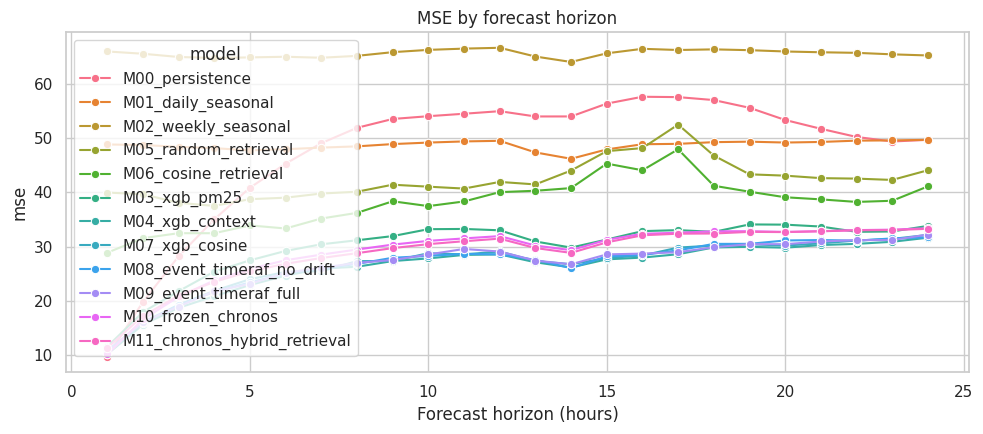

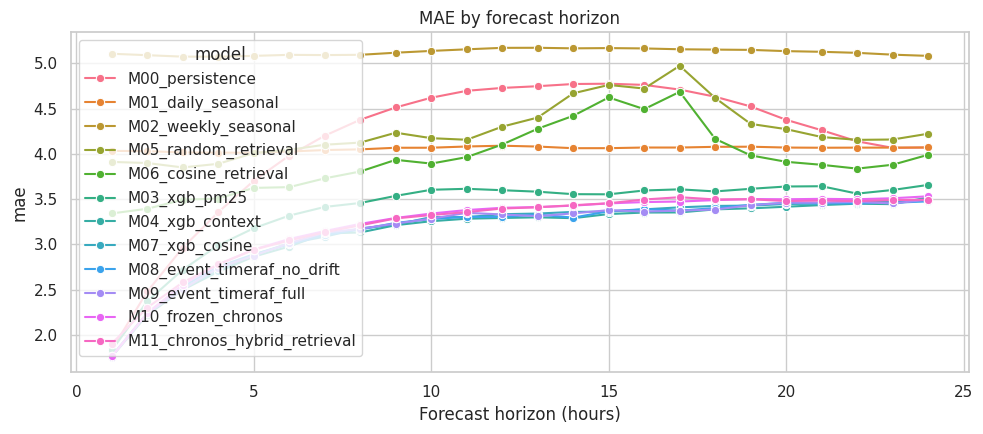

In [12]:
overall = metrics.loc[
    (metrics['horizon'].astype(str) == 'overall') & (metrics['subset'] == 'all')
    & metrics['model'].str.startswith('M')
].sort_values('mse')
display(overall)
primary_metrics = metrics.loc[metrics['model'].str.startswith('M')]
plot_horizon_metrics(primary_metrics, 'mse')
plot_horizon_metrics(primary_metrics, 'mae')
display(subset_counts)
display(ablation)


In [13]:
display(drift_results)
display(event_results)
display(explanations.sort_values('drift_score', ascending=False).head(10))


,run_id,model,drift_flag,n_origins,n_points,mse,mae,eligible_for_metrics,event_availability_mode
0,20260723T112033170131Z,A00_full_without_events,False,6639,159336,26.314863,3.084812,True,retrospective_event_start
1,20260723T112033170131Z,A00_full_without_events,True,560,13440,30.352224,3.797080,True,retrospective_event_start
2,20260723T112033170131Z,A01_xgb_random_retrieval,False,6639,159336,26.027018,3.077810,True,retrospective_event_start
3,20260723T112033170131Z,A01_xgb_random_retrieval,True,560,13440,27.902376,3.597990,True,retrospective_event_start
4,20260723T112033170131Z,M00_persistence,False,6639,159336,42.758125,4.059796,True,retrospective_event_start
5,20260723T112033170131Z,M00_persistence,True,560,13440,105.631040,5.054409,True,retrospective_event_start
6,20260723T112033170131Z,M01_daily_seasonal,False,6639,159336,38.981037,3.928030,True,retrospective_event_start
7,20260723T112033170131Z,M01_daily_seasonal,True,560,13440,164.002980,5.592046,True,retrospective_event_start
8,20260723T112033170131Z,M02_weekly_seasonal,False,6639,159336,59.889328,4.973972,True,retrospective_event_start
9,20260723T112033170131Z,M02_weekly_seasonal,True,560,13440,133.383130,6.892448,True,retrospective_event_start


,run_id,model,target_event_flag,n_origins,n_points,mse,mae,eligible_for_metrics,event_availability_mode
0,20260723T112033170131Z,A00_full_without_events,False,6667,160008,27.955952,3.189291,True,retrospective_event_start
1,20260723T112033170131Z,A00_full_without_events,True,532,12768,9.998666,2.525232,True,retrospective_event_start
2,20260723T112033170131Z,A01_xgb_random_retrieval,False,6667,160008,27.494190,3.169575,True,retrospective_event_start
3,20260723T112033170131Z,A01_xgb_random_retrieval,True,532,12768,9.614508,2.475371,True,retrospective_event_start
4,20260723T112033170131Z,M00_persistence,False,6667,160008,50.534916,4.260030,True,retrospective_event_start
5,20260723T112033170131Z,M00_persistence,True,532,12768,11.481723,2.597435,True,retrospective_event_start
6,20260723T112033170131Z,M01_daily_seasonal,False,6667,160008,51.524400,4.158085,True,retrospective_event_start
7,20260723T112033170131Z,M01_daily_seasonal,True,532,12768,13.390250,2.796585,True,retrospective_event_start
8,20260723T112033170131Z,M02_weekly_seasonal,False,6667,160008,67.917340,5.138841,True,retrospective_event_start
9,20260723T112033170131Z,M02_weekly_seasonal,True,532,12768,36.644547,4.927283,True,retrospective_event_start


,run_id,window_id,origin_time,explanation,retrieved_evidence_ids,event_evidence_ids,top_feature_effects,drift_components,retrieval_spread,validation_residual_mae,uncertainty_proxy,drift_score,drift_flag,event_availability_mode
1014,20260723T112033170131Z,w_0045838,2024-03-24 22:00:00+00:00,The mean 24-hour forecast is expected to incre...,"[""w_0017472"", ""w_0027840"", ""w_0015936""]","[""storm_1207125""]","[{""feature"": ""pm25_roll_mean_24h"", ""mean_contr...","{""mean_shift"": 0.2976033091545105, ""variance_s...",3.247217,2.936105,4.377800,0.517361,True,retrospective_event_start
295,20260723T112033170131Z,w_0045040,2024-02-20 16:00:00+00:00,The mean 24-hour forecast is expected to incre...,"[""w_0017472"", ""w_0033792"", ""w_0025920""]","[""storm_1187887"", ""storm_1187872"", ""storm_1187...","[{""feature"": ""pm25_current"", ""mean_contributio...","{""mean_shift"": 0.37620049715042114, ""variance_...",4.846405,2.936105,5.666423,0.513645,True,retrospective_event_start
296,20260723T112033170131Z,w_0045041,2024-02-20 17:00:00+00:00,The mean 24-hour forecast is expected to incre...,"[""w_0033792"", ""w_0018240"", ""w_0025920""]","[""storm_1187887"", ""storm_1187872"", ""storm_1187...","[{""feature"": ""pm25_current"", ""mean_contributio...","{""mean_shift"": 0.3683984577655792, ""variance_s...",5.898605,2.936105,6.588949,0.513623,True,retrospective_event_start
1013,20260723T112033170131Z,w_0045837,2024-03-24 21:00:00+00:00,The mean 24-hour forecast is expected to incre...,"[""w_0027840"", ""w_0028992"", ""w_0029376""]",[],"[{""feature"": ""pm25_roll_mean_24h"", ""mean_contr...","{""mean_shift"": 0.2976033091545105, ""variance_s...",3.594107,2.936105,4.640939,0.509504,True,retrospective_event_start
298,20260723T112033170131Z,w_0045043,2024-02-20 19:00:00+00:00,The mean 24-hour forecast is expected to incre...,"[""w_0025920"", ""w_0033792"", ""w_0018240""]","[""storm_1187887"", ""storm_1187872"", ""storm_1187...","[{""feature"": ""pm25_current"", ""mean_contributio...","{""mean_shift"": 0.3531515300273895, ""variance_s...",5.777996,2.936105,6.481200,0.492120,True,retrospective_event_start
1015,20260723T112033170131Z,w_0045839,2024-03-24 23:00:00+00:00,The mean 24-hour forecast is expected to incre...,"[""w_0027840"", ""w_0015936"", ""w_0029376""]","[""storm_1207125""]","[{""feature"": ""pm25_roll_mean_24h"", ""mean_contr...","{""mean_shift"": 0.3093613386154175, ""variance_s...",3.205248,2.936105,4.346760,0.484591,True,retrospective_event_start
297,20260723T112033170131Z,w_0045042,2024-02-20 18:00:00+00:00,The mean 24-hour forecast is expected to incre...,"[""w_0033792"", ""w_0025920"", ""w_0018240""]","[""storm_1187887"", ""storm_1187872"", ""storm_1187...","[{""feature"": ""pm25_current"", ""mean_contributio...","{""mean_shift"": 0.3540031909942627, ""variance_s...",6.290484,2.936105,6.941966,0.473658,True,retrospective_event_start
299,20260723T112033170131Z,w_0045044,2024-02-20 20:00:00+00:00,The mean 24-hour forecast is expected to incre...,"[""w_0025920"", ""w_0033792"", ""w_0018240""]","[""storm_1187887"", ""storm_1187872"", ""storm_1187...","[{""feature"": ""pm25_current"", ""mean_contributio...","{""mean_shift"": 0.3472176492214203, ""variance_s...",5.636920,2.936105,6.355752,0.467613,True,retrospective_event_start
1016,20260723T112033170131Z,w_0045840,2024-03-25 00:00:00+00:00,The mean 24-hour forecast is expected to incre...,"[""w_0017472"", ""w_0015936"", ""w_0029376""]","[""storm_1207126"", ""storm_1207125""]","[{""feature"": ""pm25_roll_mean_24h"", ""mean_contr...","{""mean_shift"": 0.31260302662849426, ""variance_...",3.430099,2.936105,4.515118,0.458278,True,retrospective_event_start
300,20260723T112033170131Z,w_0045045,2024-02-20 21:00:00+00:00,The mean 24-hour forecast is expected to incre...,"[""w_0033792"", ""w_0025920"", ""w_0018240""]","[""storm_1187887"", ""storm_1187872"", ""storm_1187...","[{""feature"": ""pm25_current"", ""mean_contributio...","{""mean_shift"": 0.35092633962631226, ""variance_...",6.1754